## This notebook presents the result analysis and visualization for submission NCOMMS-26-018997-T

**Title:** *Impacts and Benefits of Electrified Space Heating on Renewable-Based Power Systems*

This notebook contains the analysis of simulation results and the corresponding visualizations prepared for the above submission.

Supplementary Figure 2: Daily normalized individual HP demand versus daily average ambient temperature,
differentiated by building construction type and construction year.

**Contact:** Yi Guo  
**Email:** yi.guo@bit.edu.cn

### Supplementary Figure 2

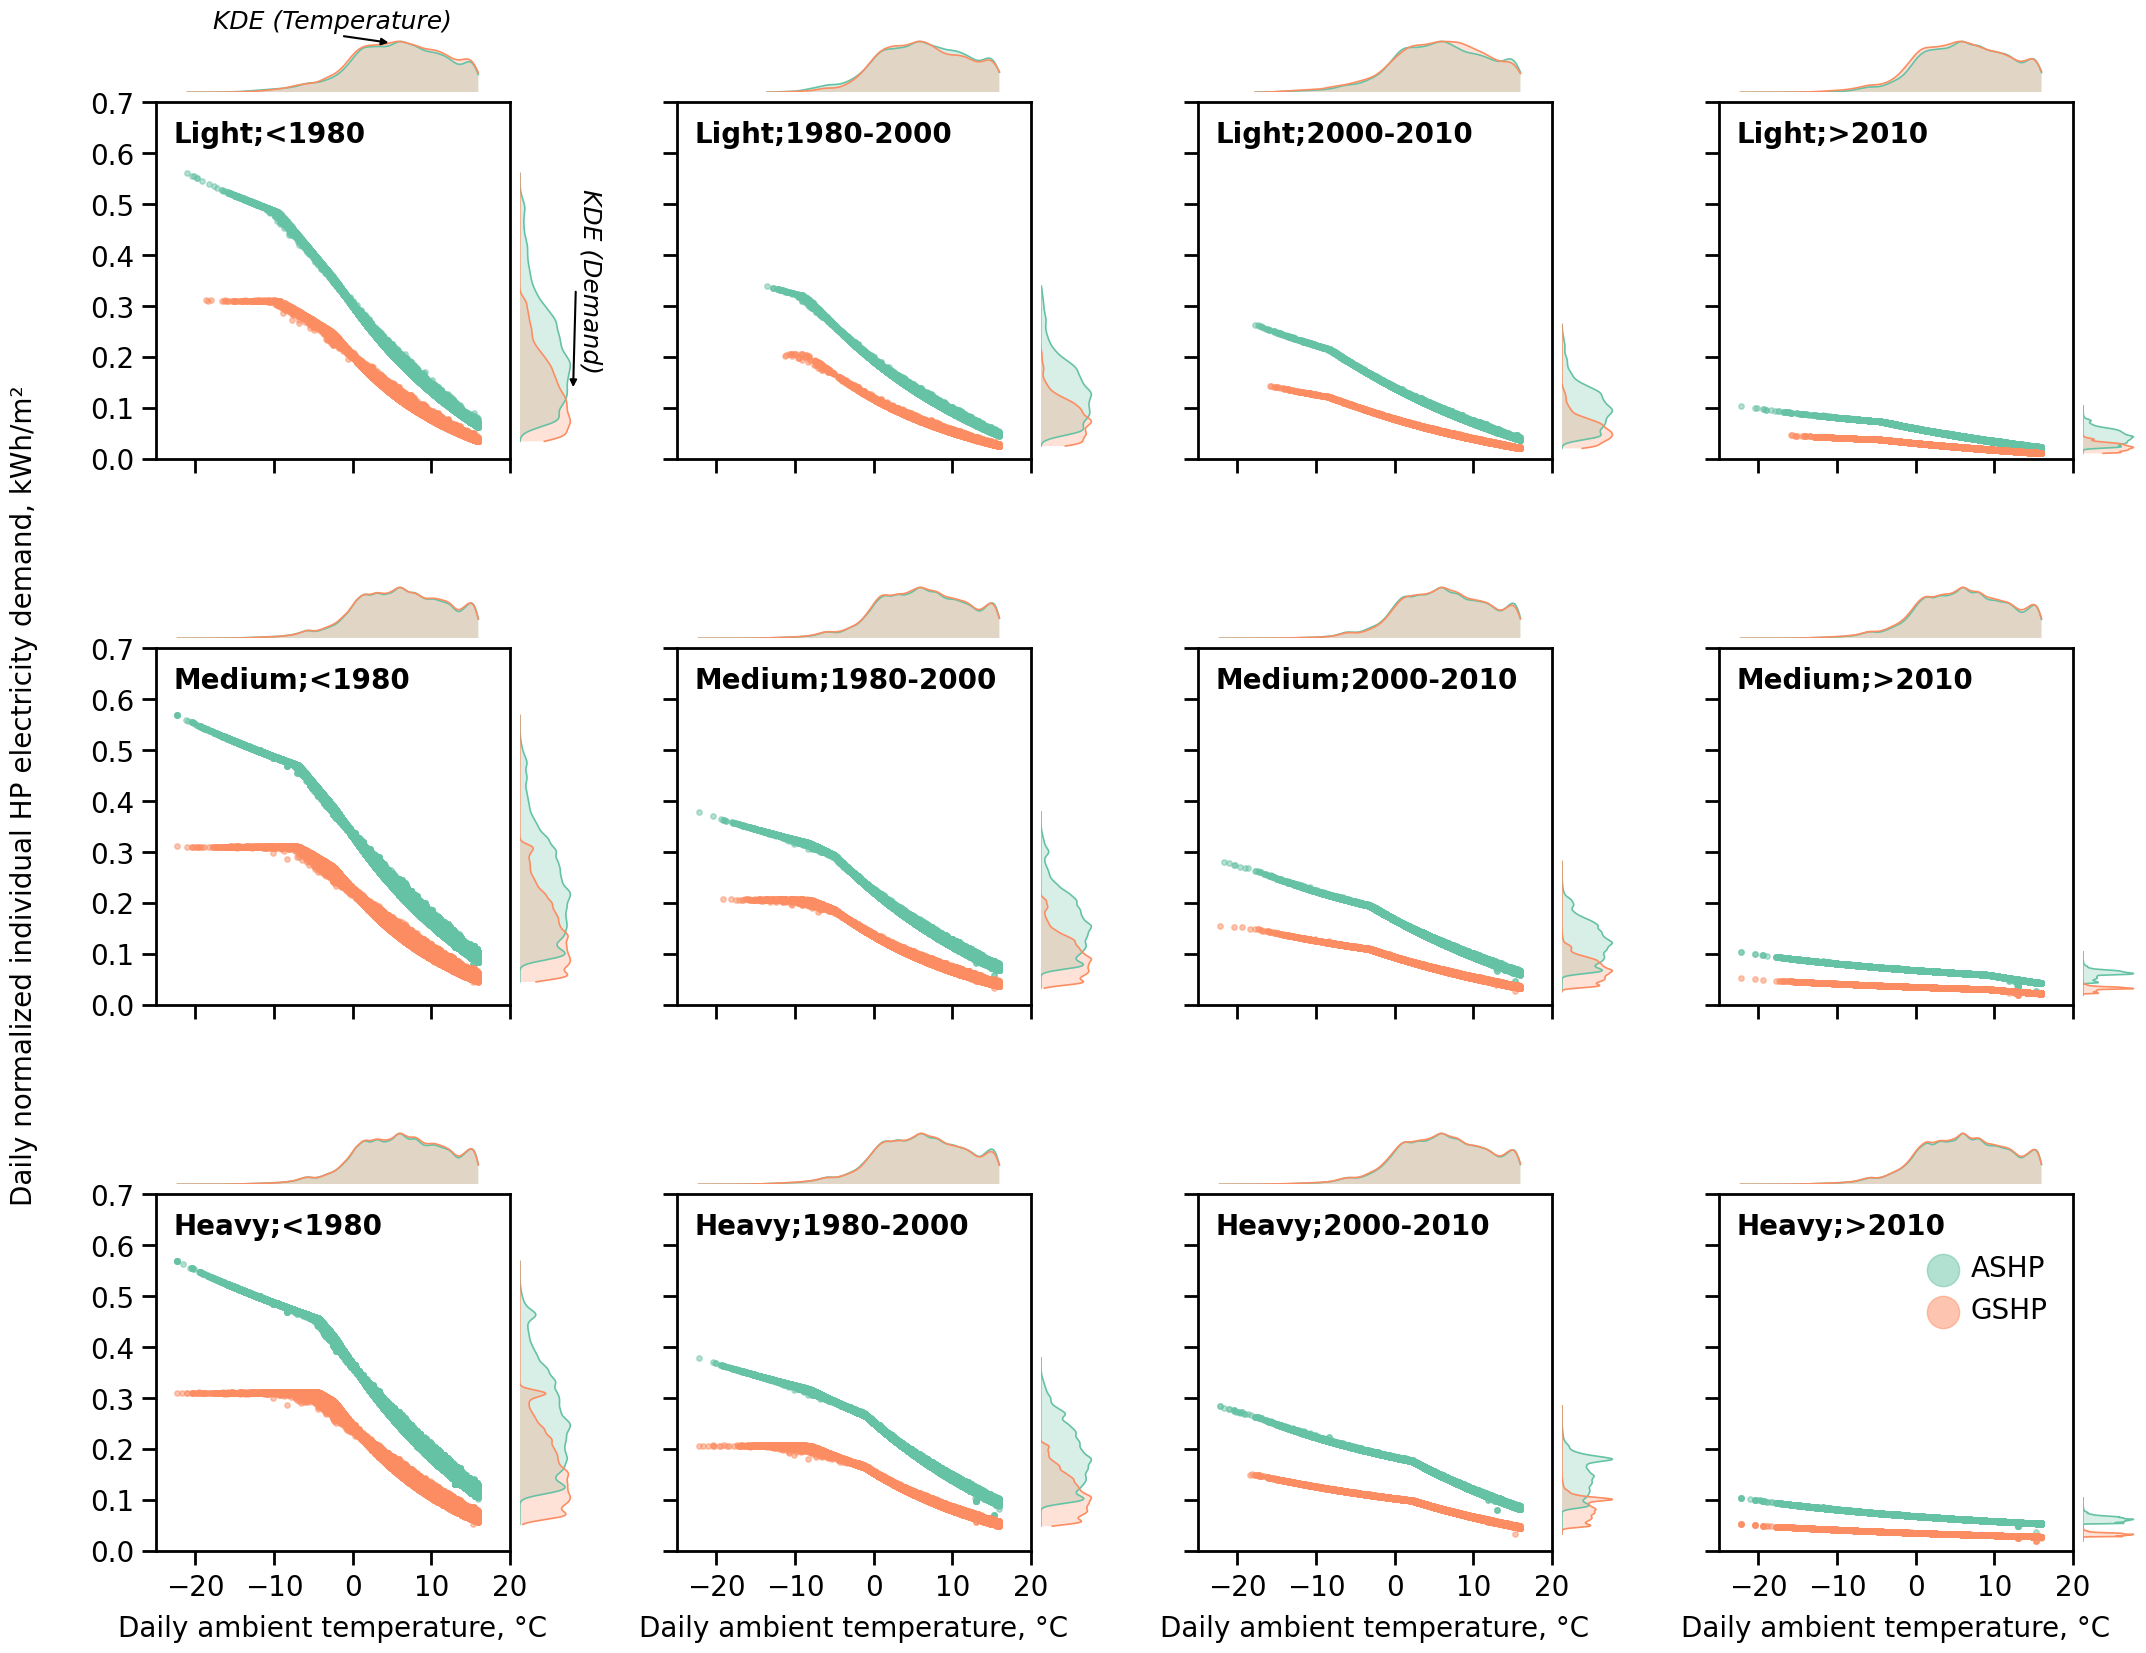

In [1]:
# ==============================================================================
# This cell analyses and visualizes the results as shown in Supplementary Fig. 2
# ==============================================================================

# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.stats import gaussian_kde
import os
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from pathlib import Path


# =============== Parameters ===============
label_font_size = 20
tick_font_size = 20
sublabel_font_size = 20
labelpad_size = 10
line_width = 2
marker_size = 15
legend_font_size = 20

# Ticks (outward only)
MAJOR_TICK_LEN = 10
MINOR_TICK_LEN = 6
TICK_PAD = 6

# Automatic tick intervals
X_MAJOR_STEP = 10
X_MINOR_STEP = 10
Y_MAJOR_STEP = 0.1
Y_MINOR_STEP = 0.1

# Colors
COLORS = {"ASHP": "#66c2a5", "GSHP": "#fc8d62"}

ALPHA_PT = 0.5
ALPHA_KDE = 0.25
KDE_N = 256

# KDE annotation style
KDE_TEXT_KW = dict(fontsize=18, fontstyle='italic',
                   bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
KDE_ARROW_KW = dict(arrowstyle='-|>', color='black', lw=1.5, shrinkA=8, shrinkB=8)

# =============== Styling functions ===============
def apply_axis_style(ax):
    ax.tick_params(axis='both', which='major',
                   direction='out', length=MAJOR_TICK_LEN, width=2.0,
                   colors='black', pad=TICK_PAD)
    ax.tick_params(axis='both', which='minor',
                   direction='out', length=MINOR_TICK_LEN, width=1.5,
                   colors='black', pad=TICK_PAD)
    for sp in ax.spines.values():
        sp.set_linewidth(line_width); sp.set_color('black')
    ax.tick_params(labelsize=tick_font_size)
    ax.minorticks_on(); ax.grid(False); ax.set_axisbelow(False)

def set_locators(ax, x_major=X_MAJOR_STEP, x_minor=X_MINOR_STEP,
                 y_major=Y_MAJOR_STEP, y_minor=Y_MINOR_STEP):
    if x_major: ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if x_minor: ax.xaxis.set_minor_locator(MultipleLocator(x_minor))
    if y_major: ax.yaxis.set_major_locator(MultipleLocator(y_major))
    if y_minor: ax.yaxis.set_minor_locator(MultipleLocator(y_minor))

def safe_flat(a): return np.squeeze(a).flatten()

def kde_1d(values, xmin, xmax, n=KDE_N, bw=None):
    v = np.asarray(values); v = v[np.isfinite(v)]
    if v.size < 5 or np.allclose(v.min(), v.max()): return None
    kde = gaussian_kde(v, bw_method=bw)
    grid = np.linspace(xmin, xmax, n); pdf = kde(grid)
    if pdf.max() > 0: pdf = pdf / pdf.max()
    return grid, pdf

def annotate_kde_pretty(ax_top, ax_right, kdet1, kdet2, kdee1, kdee2):
    # Top axis (temperature)
    if (kdet1 is not None) or (kdet2 is not None):
        if kdet1 is not None and kdet2 is not None:
            gx = kdet1[0]; gsum = kdet1[1] + kdet2[1]
        elif kdet1 is not None: gx, gsum = kdet1
        else: gx, gsum = kdet2
        x_peak = gx[np.argmax(gsum)]
        ax_top.text(0.5, 1.10, "KDE (Temperature)", transform=ax_top.transAxes,
                    ha='center', va='bottom', **KDE_TEXT_KW)
        ax_top.annotate('', xy=(x_peak, 0.9), xycoords=('data', 'axes fraction'),
                        xytext=(0.5, 1.08), textcoords='axes fraction',
                        arrowprops=KDE_ARROW_KW)

    # 右侧（需求）
    if (kdee1 is not None) or (kdee2 is not None):
        if kdee1 is not None and kdee2 is not None:
            gy = kdee1[0]; gsum = kdee1[1] + kdee2[1]
        elif kdee1 is not None: gy, gsum = kdee1
        else: gy, gsum = kdee2
        y_peak = gy[np.argmax(gsum)]
        ax_right.text(1.10, 0.5, "KDE (Demand)", transform=ax_right.transAxes,
                      rotation=270, ha='left', va='center', **KDE_TEXT_KW)
        ax_right.annotate('', xy=(1.0, y_peak), xycoords=('axes fraction', 'data'),
                          xytext=(1.06, 0.5), textcoords='axes fraction',
                          arrowprops=KDE_ARROW_KW)

def draw_panel(ax_main, t1, e1, t2, e2, title_text,
               xlim=(-25, 20), ylim=(0, 0.7),
               first_panel=False, put_legend=False):
    ax_main.set_xlim(*xlim); ax_main.set_ylim(*ylim)
    ax_main.scatter(t1, e1, s=marker_size, alpha=ALPHA_PT, color=COLORS["ASHP"], label='ASHP', rasterized=True)
    ax_main.scatter(t2, e2, s=marker_size, alpha=ALPHA_PT, color=COLORS["GSHP"], label='GSHP', rasterized=True)
    ax_main.text(0.05, 0.95, title_text, transform=ax_main.transAxes,
                 fontsize=sublabel_font_size, va='top', ha='left', weight='bold')
    apply_axis_style(ax_main); set_locators(ax_main)

    divider = make_axes_locatable(ax_main)
    ax_top   = divider.append_axes("top",   size="15%", pad=0.1, sharex=ax_main)
    ax_right = divider.append_axes("right", size="15%", pad=0.1, sharey=ax_main)

    tmin, tmax = min(np.min(t1), np.min(t2)), max(np.max(t1), np.max(t2))
    emin, emax = min(np.min(e1), np.min(e2)), max(np.max(e1), np.max(e2))

    kdet1 = kde_1d(t1, tmin, tmax); kdet2 = kde_1d(t2, tmin, tmax)
    kdee1 = kde_1d(e1, emin, emax); kdee2 = kde_1d(e2, emin, emax)

    if kdet1 is not None:
        gx, gpdf = kdet1
        ax_top.fill_between(gx, 0, gpdf, alpha=ALPHA_KDE, edgecolor='none', facecolor=COLORS["ASHP"])
        ax_top.plot(gx, gpdf, linewidth=1.2, color=COLORS["ASHP"])
    if kdet2 is not None:
        gx, gpdf = kdet2
        ax_top.fill_between(gx, 0, gpdf, alpha=ALPHA_KDE, edgecolor='none', facecolor=COLORS["GSHP"])
        ax_top.plot(gx, gpdf, linewidth=1.2, color=COLORS["GSHP"])
    ax_top.set_ylim(0, 1.05); ax_top.axis("off")

    if kdee1 is not None:
        gy, gpdf = kdee1
        ax_right.fill_betweenx(gy, 0, gpdf, alpha=ALPHA_KDE, edgecolor='none', facecolor=COLORS["ASHP"])
        ax_right.plot(gpdf, gy, linewidth=1.2, color=COLORS["ASHP"])
    if kdee2 is not None:
        gy, gpdf = kdee2
        ax_right.fill_betweenx(gy, 0, gpdf, alpha=ALPHA_KDE, edgecolor='none', facecolor=COLORS["GSHP"])
        ax_right.plot(gpdf, gy, linewidth=1.2, color=COLORS["GSHP"])
    ax_right.set_xlim(0, 1.05)
    ax_right.axis("off")

    if first_panel:
        annotate_kde_pretty(ax_top, ax_right, kdet1, kdet2, kdee1, kdee2)

    if put_legend:
        ax_main.legend(loc='upper right', bbox_to_anchor=(1, 0.9), frameon=False, fontsize=legend_font_size,
                       handlelength=1.2, handletextpad=0.4, markerscale = 6)

# =============== Load data ===============
base_path = r'../Output_data'
file_name = r'flexibility_temperature_ch_2024_Tset22.0_10000_RCP26_Quant50_Category II.mat'
full_path = os.path.join(base_path, file_name)
results = scipy.io.loadmat(full_path)['results'][0, 0]

# Grouping indices
group_indices = []
for iHP in (1, 2):
    for ibc in (1, 2, 3):
        for iyg in (1, 2, 3, 4):
            idx = np.where(
                (results['HP_type'] == iHP) &
                (results['building_construction'] == ibc) &
                (results['building_year_group'] == iyg)
            )[0]
            group_indices.append(idx)

subplot_titles = [
    "Light;<1980", "Light;1980-2000", "Light;2000-2010", "Light;>2010",
    "Medium;<1980", "Medium;1980-2000", "Medium;2000-2010", "Medium;>2010",
    "Heavy;<1980", "Heavy;1980-2000", "Heavy;2000-2010", "Heavy;>2010"
]

# =============== Plotting routine (3×4, 12 subplots) ===============
xlim = (-25, 20); ylim = (0, 0.7)

fig = plt.figure(figsize=(22, 18))
gs = GridSpec(3, 4, figure=fig, left=0.08, right=0.98, top=0.92, bottom=0.08, wspace=0.25, hspace=0.3)
# Increase the left margin slightly to 0.08 to make room for the shared y-axis label

selected_idx = list(range(12))

axes_main = []
for j, i in enumerate(selected_idx):
    row, col = divmod(j, 4)

    t1 = safe_flat(results['avg_temp'][group_indices[i], :])
    e1 = safe_flat(results['baseline_energy_per_m2'][group_indices[i], :])
    t2 = safe_flat(results['avg_temp'][group_indices[i + 12], :])
    e2 = safe_flat(results['baseline_energy_per_m2'][group_indices[i + 12], :])

    m1 = e1 != 0; m2 = e2 != 0
    t1, e1 = t1[m1], e1[m1]
    t2, e2 = t2[m2], e2[m2]

    ax = fig.add_subplot(gs[row, col]); axes_main.append(ax)
    if t1.size == 0 or t2.size == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=sublabel_font_size, alpha=0.6)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        apply_axis_style(ax); set_locators(ax)
        continue

    draw_panel(ax, t1, e1, t2, e2, subplot_titles[i],
               xlim=xlim, ylim=ylim,
               first_panel=(j == 0),
               put_legend=(j == 11))

# ======== Outer-axis labels ========
for j, ax in enumerate(axes_main):
    row, col = divmod(j, 4)

    # Show x-axis labels only on the bottom row
    if row == 2:
        ax.set_xlabel("Daily ambient temperature, °C",
                      fontsize=label_font_size, labelpad=labelpad_size)
        ax.tick_params(labelbottom=True)
    else:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)

    # Show y-axis ticks only in the leftmost column, but suppress per-panel y-labels to avoid overlap
    if col == 0:
        ax.set_ylabel("")           # Do not assign text here
        ax.tick_params(labelleft=True)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

# ======== Shared y-axis label (displayed only once)========
fig.text(0.02, 0.5,
         "Daily normalized individual HP electricity demand, kWh/m²",
         rotation=90, va='center', ha='center', fontsize=label_font_size)
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'

# ======================= Additional step: SVG export (text remains editable in Adobe Illustrator) =======================
# Keep SVG text as editable text rather than converting it to paths
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False      # Disable LaTeX text rendering to avoid converting text to outlines
mpl.rcParams['font.family'] = ['Arial']

# # Export path (modify as needed)
# out_path = Path.cwd() / "Main_SI_fig2.svg"

# # Save as SVG with a transparent background and tight bounding box
# fig.savefig(
#     out_path,
#     format="svg",
#     bbox_inches="tight",
#     pad_inches=0.02,
#     facecolor='none',
#     edgecolor='none',
#     transparent=True
# )
# print(f"Saved SVG to: {out_path}")
# ================================================================================

plt.show()
